### Langchain Version v1

In [1]:
import langchain

langchain.__version__

'1.4.0'

In [2]:
import os
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain.agents import create_agent

load_dotenv()


True

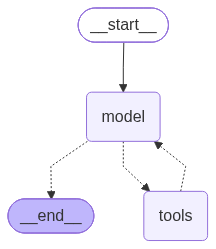

In [3]:

# 1. Initialize Groq model
model = ChatGroq(
    model="openai/gpt-oss-120b",
    groq_api_key=os.getenv("GROQ_API_KEY"),
    temperature=0,
)

# 2. Define the tool
@tool
def get_weather(city: str) -> str:
    """Get the weather for the given city."""
    return f"The weather in {city} is sunny."

# 3. Create agent
agent = create_agent(
    model=model,
    tools=[get_weather],
)

agent

In [4]:

# 4. Run agent
response = agent.invoke({
    "messages": [
        ("user", "What is the weather in Kochi?")
    ]
})

response

{'messages': [HumanMessage(content='What is the weather in Kochi?', additional_kwargs={}, response_metadata={}, id='c442a3cb-df88-44c1-802c-d116b32d4bb0'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is the weather in Kochi?" Need to fetch weather via function get_weather. Use function.', 'tool_calls': [{'id': 'fc_f2f57824-d6db-45d7-84a5-363d34ad1803', 'function': {'arguments': '{"city":"Kochi"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 129, 'total_tokens': 183, 'completion_time': 0.114580481, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.006941961, 'prompt_tokens_details': None, 'queue_time': 0.336601476, 'total_time': 0.121522442}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_77b12279f9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a603-5b5d-786

In [5]:
# 5. Get final response
print(response["messages"][-1].content)

The current weather in Kochi is sunny.


In [6]:
agent.invoke({"messages":"What is the weather in Kochi"})

{'messages': [HumanMessage(content='What is the weather in Kochi', additional_kwargs={}, response_metadata={}, id='e9f20abf-d74d-4f46-bc6f-4734ad1c5818'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the weather in Kochi". We need to get weather. Use function get_weather with city "Kochi".', 'tool_calls': [{'id': 'fc_319e0d13-03b5-4b1d-831c-b6ee7d3d3846', 'function': {'arguments': '{"city":"Kochi"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 128, 'total_tokens': 188, 'completion_time': 0.129434381, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.007736345, 'prompt_tokens_details': None, 'queue_time': 0.348433342, 'total_time': 0.137170726}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_fe269835c7', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a603

In [7]:
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [8]:

from langchain.chat_models import init_chat_model

model = init_chat_model("groq:openai/gpt-oss-120b")

model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x10ca35bd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10ca37250>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [9]:
#invoke the model

response = model.invoke("Hello, How are you?")

response

AIMessage(content='Hello! I’m doing great, thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The system message says we are ChatGPT, large language model. The developer message says "You are ChatGPT, a large language model trained by OpenAI." The user says "Hello, How are you?" So a friendly response. Probably just a brief greeting.'}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 77, 'total_tokens': 166, 'completion_time': 0.193406952, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.015504795, 'prompt_tokens_details': None, 'queue_time': 0.798842878, 'total_time': 0.208911747}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_1d982b31b2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a603-6593-76c1-b667-1fbe537064aa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_t

In [10]:
response.content

'Hello! I’m doing great, thanks for asking. How can I help you today?'

In [13]:
for chunk in model.stream("write me a 1000 words paragraph about AI"):

    print(chunk.text, end="|", flush=True)

|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Artificial| intelligence|,| a| term| that| once| belonged| solely| to| the| realms| of| speculative| fiction| and| philosophical| debate|,| has| evolved| over| the| past| several| decades| into| a| pervasive| and| transformative| force| that| resh|apes| economies|,| societies|,| scientific| inquiry|,| and| the| very| fabric| of| daily| human| experience|,| and| its| story| begins| in| the| mid|‑|tw|entieth| century| when| pioneers| such| as| Alan| T|uring| posed| the| fundamental| question| of| whether| machines| could| think|,| an| inquiry| that| led| to| the| formulation| of| the| T|uring| Test| as| a| benchmark| for| machine| in

In [16]:
responses = model.batch([

"Why birds can fly?", "Write about AI","Write about cristiano ronaldo"
]
)

config = { 'max_concurrency':5}

for response in responses:

    print(response)

content='Birds can fly because their bodies are specially adapted to generate **lift** and **thrust** while minimizing weight and drag. The main factors are:\n\n| Feature | How it helps flight |\n|---------|---------------------|\n| **Wing shape (airfoil)** | The curved upper surface makes air move faster over the top than underneath, creating lower pressure above the wing (Bernoulli’s principle) and higher pressure below. This pressure difference produces lift. |\n| **Feathers** | – **Flight feathers** are stiff, lightweight, and have a cambered (curved) shape that forms the airfoil.<br>– **Alula** (a small “thumb” feather) can be spread to control airflow at low speeds, preventing stall.<br>– **Down feathers** provide insulation without adding much weight. |\n| **Powerful flight muscles** | The **pectoralis** (downstroke) and **supracoracoideus** (upstroke) muscles contract rapidly, moving the wings and providing thrust. These muscles make up a large fraction of a bird’s body mass (u